In [3]:
import pandas as pd
import numpy as np
import sqlite3
from datetime import datetime, timedelta

np.random.seed(42)

# =========================
# 1. GENERATE BUSINESS DATA
# =========================

customers = pd.DataFrame({
    "customer_id": range(1, 501),
    "customer_name": [f"Customer_{i}" for i in range(1, 501)],
    "region": np.random.choice(["North", "South", "East", "West"], 500),
    "customer_segment": np.random.choice(["Consumer", "Corporate", "Small Business"], 500),
    "signup_date": pd.to_datetime("2023-01-01") + pd.to_timedelta(
        np.random.randint(0, 700, 500), unit="D"
    )
})

products = pd.DataFrame({
    "product_id": range(1, 31),
    "product_name": [f"Product_{i}" for i in range(1, 31)],
    "category": np.random.choice(["Technology", "Furniture", "Office Supplies"], 30),
    "unit_cost": np.random.randint(20, 300, 30)
})

orders = pd.DataFrame({
    "order_id": range(1, 3001),
    "customer_id": np.random.choice(customers["customer_id"], 3000),
    "product_id": np.random.choice(products["product_id"], 3000),
    "order_date": pd.to_datetime("2024-01-01") + pd.to_timedelta(
        np.random.randint(0, 365, 3000), unit="D"
    ),
    "quantity": np.random.randint(1, 8, 3000),
    "discount": np.random.choice([0, 0.05, 0.10, 0.15, 0.20], 3000)
})

orders = orders.merge(products[["product_id", "unit_cost"]], on="product_id")
orders["unit_price"] = orders["unit_cost"] * np.random.uniform(1.3, 2.2, len(orders))
orders["revenue"] = orders["quantity"] * orders["unit_price"] * (1 - orders["discount"])
orders["profit"] = orders["revenue"] - (orders["quantity"] * orders["unit_cost"])

orders["unit_price"] = orders["unit_price"].round(2)
orders["revenue"] = orders["revenue"].round(2)
orders["profit"] = orders["profit"].round(2)

# =========================
# 2. LOAD INTO SQLITE
# =========================

conn = sqlite3.connect(":memory:")

customers.to_sql("customers", conn, index=False, if_exists="replace")
products.to_sql("products", conn, index=False, if_exists="replace")
orders.to_sql("orders", conn, index=False, if_exists="replace")

def sql(query):
    return pd.read_sql_query(query, conn)

# =========================
# 3. ADVANCED SQL QUERIES
# =========================

# KPI Summary
kpi_summary = sql("""
SELECT
    ROUND(SUM(revenue), 2) AS total_revenue,
    ROUND(SUM(profit), 2) AS total_profit,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_id) AS active_customers,
    ROUND(SUM(revenue) / COUNT(DISTINCT order_id), 2) AS avg_order_value,
    ROUND(SUM(profit) * 100.0 / SUM(revenue), 2) AS profit_margin_percent
FROM orders;
""")

kpi_summary

,total_revenue,total_profit,total_orders,active_customers,avg_order_value,profit_margin_percent
0,2717257.82,992818.82,3000,496,905.75,36.54


In [5]:
# Monthly revenue trend using CTE
monthly_revenue = sql("""
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', order_date) AS month,
        ROUND(SUM(revenue), 2) AS monthly_revenue,
        ROUND(SUM(profit), 2) AS monthly_profit
    FROM orders
    GROUP BY month
)
SELECT
    month,
    monthly_revenue,
    monthly_profit,
    ROUND(
        monthly_revenue - LAG(monthly_revenue) OVER (ORDER BY month),
        2
    ) AS revenue_change,
    ROUND(
        (monthly_revenue - LAG(monthly_revenue) OVER (ORDER BY month)) 
        * 100.0 / LAG(monthly_revenue) OVER (ORDER BY month),
        2
    ) AS revenue_growth_percent
FROM monthly_sales;
""")

monthly_revenue

,month,monthly_revenue,monthly_profit,revenue_change,revenue_growth_percent
0,2024-01,250102.34,92331.34,NaN,NaN
1,2024-02,182790.60,65776.60,-67311.74,-26.91
2,2024-03,228352.72,82387.72,45562.12,24.93
3,2024-04,249088.54,95258.54,20735.82,9.08
4,2024-05,240879.13,90015.13,-8209.41,-3.30
5,2024-06,215336.79,75956.79,-25542.34,-10.60
6,2024-07,241161.10,85145.10,25824.31,11.99
7,2024-08,213694.28,76886.28,-27466.82,-11.39
8,2024-09,220216.86,81983.86,6522.58,3.05
9,2024-10,221391.53,79930.53,1174.67,0.53


In [7]:
# Top products by revenue using RANK
top_products = sql("""
WITH product_sales AS (
    SELECT
        p.product_name,
        p.category,
        ROUND(SUM(o.revenue), 2) AS total_revenue,
        ROUND(SUM(o.profit), 2) AS total_profit,
        SUM(o.quantity) AS units_sold
    FROM orders o
    JOIN products p ON o.product_id = p.product_id
    GROUP BY p.product_name, p.category
)
SELECT
    product_name,
    category,
    total_revenue,
    total_profit,
    units_sold,
    RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank
FROM product_sales
LIMIT 10;
""")

top_products

,product_name,category,total_revenue,total_profit,units_sold,revenue_rank
0,Product_13,Furniture,167231.41,63171.41,473,1
1,Product_26,Office Supplies,164911.53,58767.53,428,2
2,Product_5,Technology,156248.20,56608.20,376,3
3,Product_11,Technology,155489.49,59057.49,392,4
4,Product_12,Furniture,144167.14,52117.14,350,5
5,Product_19,Office Supplies,143588.84,53200.84,383,6
6,Product_9,Technology,137095.31,50923.31,334,7
7,Product_7,Furniture,136093.43,46785.43,332,8
8,Product_16,Furniture,134704.61,49344.61,388,9
9,Product_4,Technology,116887.21,41647.21,440,10


In [9]:
# Top customers using ROW_NUMBER
top_customers = sql("""
WITH customer_sales AS (
    SELECT
        c.customer_id,
        c.customer_name,
        c.region,
        c.customer_segment,
        ROUND(SUM(o.revenue), 2) AS total_revenue,
        COUNT(o.order_id) AS order_count
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.customer_id, c.customer_name, c.region, c.customer_segment
)
SELECT
    *,
    ROW_NUMBER() OVER (ORDER BY total_revenue DESC) AS customer_rank
FROM customer_sales
LIMIT 10;
""")

top_customers

,customer_id,customer_name,region,customer_segment,total_revenue,order_count,customer_rank
0,425,Customer_425,West,Small Business,14433.65,11,1
1,12,Customer_12,East,Corporate,14051.21,14,2
2,375,Customer_375,North,Consumer,12838.61,9,3
3,183,Customer_183,South,Consumer,12693.35,10,4
4,213,Customer_213,North,Small Business,12327.51,10,5
5,288,Customer_288,North,Small Business,12272.30,10,6
6,47,Customer_47,West,Small Business,12149.05,10,7
7,380,Customer_380,North,Consumer,12091.33,9,8
8,432,Customer_432,South,Corporate,11794.01,10,9
9,314,Customer_314,East,Corporate,11583.79,9,10


In [11]:
# Customer behavior by segment
customer_behavior = sql("""
SELECT
    c.customer_segment,
    COUNT(DISTINCT c.customer_id) AS customers,
    COUNT(o.order_id) AS total_orders,
    ROUND(SUM(o.revenue), 2) AS total_revenue,
    ROUND(SUM(o.revenue) / COUNT(DISTINCT c.customer_id), 2) AS revenue_per_customer,
    ROUND(COUNT(o.order_id) * 1.0 / COUNT(DISTINCT c.customer_id), 2) AS orders_per_customer
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_segment
ORDER BY total_revenue DESC;
""")

customer_behavior

,customer_segment,customers,total_orders,total_revenue,revenue_per_customer,orders_per_customer
0,Consumer,184,1139,1004838.92,5461.08,6.19
1,Corporate,165,1025,933534.56,5657.79,6.21
2,Small Business,147,836,778884.34,5298.53,5.69


In [13]:
# Regional performance
regional_performance = sql("""
SELECT
    c.region,
    ROUND(SUM(o.revenue), 2) AS total_revenue,
    ROUND(SUM(o.profit), 2) AS total_profit,
    COUNT(DISTINCT o.customer_id) AS active_customers,
    ROUND(SUM(o.profit) * 100.0 / SUM(o.revenue), 2) AS profit_margin_percent
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.region
ORDER BY total_revenue DESC;
""")

regional_performance

,region,total_revenue,total_profit,active_customers,profit_margin_percent
0,West,772961.58,282027.58,147,36.49
1,North,681032.26,245877.26,121,36.10
2,East,662427.65,241685.65,121,36.48
3,South,600836.33,223228.33,107,37.15


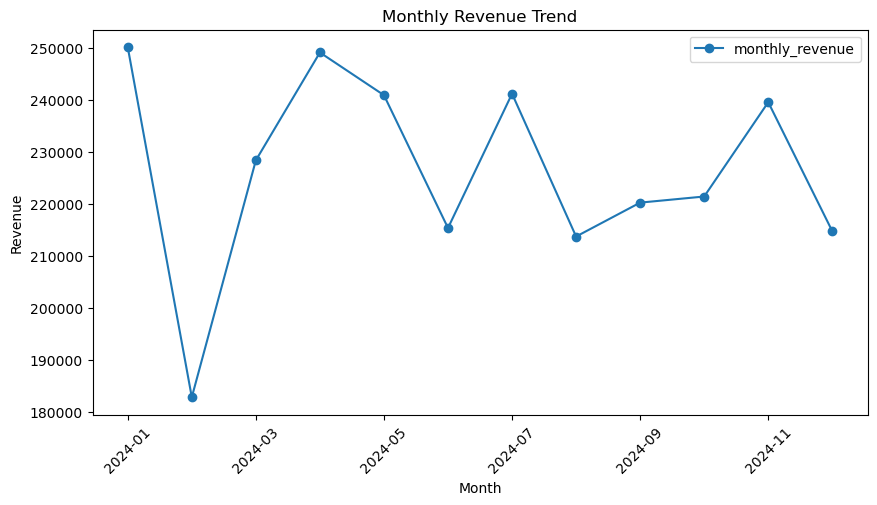

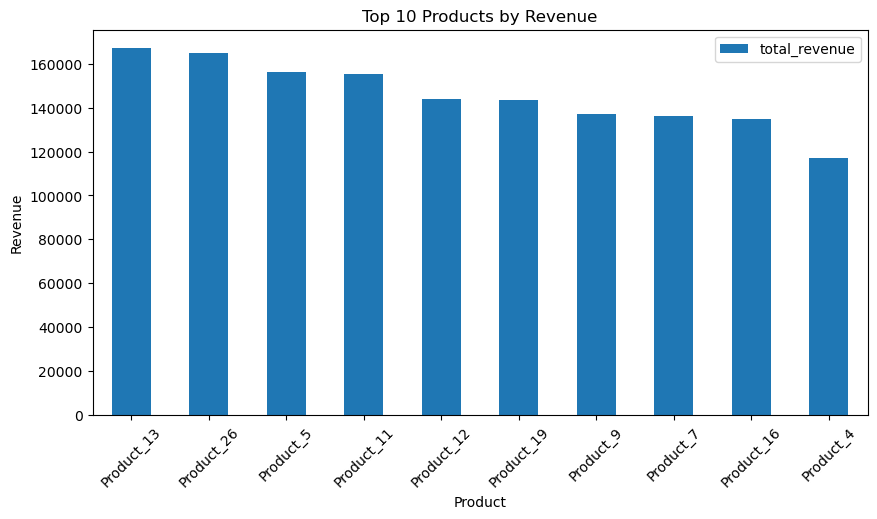

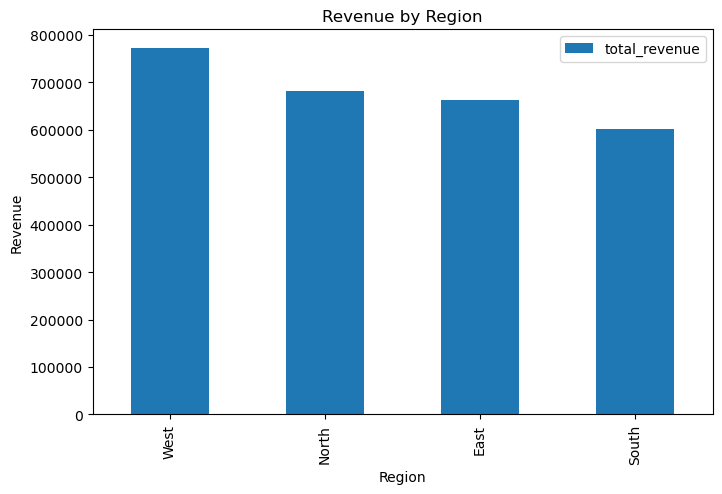

In [15]:
# =========================
# 4. VISUAL ANALYSIS
# =========================

import matplotlib.pyplot as plt

monthly_revenue.plot(
    x="month",
    y="monthly_revenue",
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Monthly Revenue Trend"
)
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.show()

top_products.plot(
    x="product_name",
    y="total_revenue",
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Products by Revenue"
)
plt.ylabel("Revenue")
plt.xlabel("Product")
plt.xticks(rotation=45)
plt.show()

regional_performance.plot(
    x="region",
    y="total_revenue",
    kind="bar",
    figsize=(8, 5),
    title="Revenue by Region"
)
plt.ylabel("Revenue")
plt.xlabel("Region")
plt.show()

In [17]:
# =========================
# 5. AUTO-GENERATED INSIGHTS
# =========================

best_month = monthly_revenue.sort_values("monthly_revenue", ascending=False).iloc[0]
best_product = top_products.iloc[0]
best_customer = top_customers.iloc[0]
best_region = regional_performance.iloc[0]
best_segment = customer_behavior.iloc[0]

print("KPI SUMMARY")
print(kpi_summary.to_string(index=False))

print("\nBUSINESS INSIGHTS")
print(f"1. Highest revenue month was {best_month['month']} with revenue of ${best_month['monthly_revenue']:,.2f}.")
print(f"2. Top product was {best_product['product_name']} in the {best_product['category']} category, generating ${best_product['total_revenue']:,.2f}.")
print(f"3. Best customer was {best_customer['customer_name']}, generating ${best_customer['total_revenue']:,.2f} across {best_customer['order_count']} orders.")
print(f"4. Strongest region was {best_region['region']} with ${best_region['total_revenue']:,.2f} in revenue.")
print(f"5. Most valuable customer segment was {best_segment['customer_segment']} with ${best_segment['total_revenue']:,.2f} in revenue.")

print("\nBUSINESS IMPACT RECOMMENDATIONS")
print("- Focus marketing campaigns on the highest-revenue customer segment.")
print("- Increase inventory and promotion for the top-performing products.")
print("- Study the strongest region and apply similar sales strategies to weaker regions.")
print("- Create loyalty offers for top customers to improve retention.")
print("- Monitor monthly revenue growth to identify seasonal demand patterns.")

KPI SUMMARY
 total_revenue  total_profit  total_orders  active_customers  avg_order_value  profit_margin_percent
    2717257.82     992818.82          3000               496           905.75                  36.54

BUSINESS INSIGHTS
1. Highest revenue month was 2024-01 with revenue of $250,102.34.
2. Top product was Product_13 in the Furniture category, generating $167,231.41.
3. Best customer was Customer_425, generating $14,433.65 across 11 orders.
4. Strongest region was West with $772,961.58 in revenue.
5. Most valuable customer segment was Consumer with $1,004,838.92 in revenue.

BUSINESS IMPACT RECOMMENDATIONS
- Focus marketing campaigns on the highest-revenue customer segment.
- Increase inventory and promotion for the top-performing products.
- Study the strongest region and apply similar sales strategies to weaker regions.
- Create loyalty offers for top customers to improve retention.
- Monitor monthly revenue growth to identify seasonal demand patterns.
